<a href="https://colab.research.google.com/github/lukazsw/Machine-Learning-2025L/blob/main/lw430257_homework02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praca Domowa: LAB02_CLUSTERING

# Autor: Łukasz Wysocki

Celem tej pracy jest odpowiedź na dwa pytania:

1. Jak zwizualizować granicę decyzyjną modelu Gaussian Mixture Model (GMM) dopasowanego algorytmem EM do danych 2D?
2. Jak wybrać odpowiednią liczbę klastrów, gdy nie jest ona znana z góry?

W pierwszej części użyję zbioru danych 2D i pokażę:
- dane,
- przypisania do klastrów,
- obszary decyzyjne modelu GMM.

W drugiej części porównam różne wartości $k$ za pomocą metryk takich jak inertia i silhouette score.

In [30]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [31]:
np.random.seed(0)

mean1 = np.array([0.0, 0.0])
cov1 = np.array([[0.16, 0.0],
                 [0.0, 0.16]])
data1 = np.random.multivariate_normal(mean1, cov1, 300)

mean2 = np.array([0.8, 0.8])
cov2 = np.array([[0.04, 0.0],
                 [0.0, 0.04]])
data2 = np.random.multivariate_normal(mean2, cov2, 100)

mean3 = np.array([-0.8, 0.8])
cov3 = np.array([[0.04, 0.0],
                 [0.0, 0.04]])
data3 = np.random.multivariate_normal(mean3, cov3, 100)

X = np.vstack([data1, data2, data3])

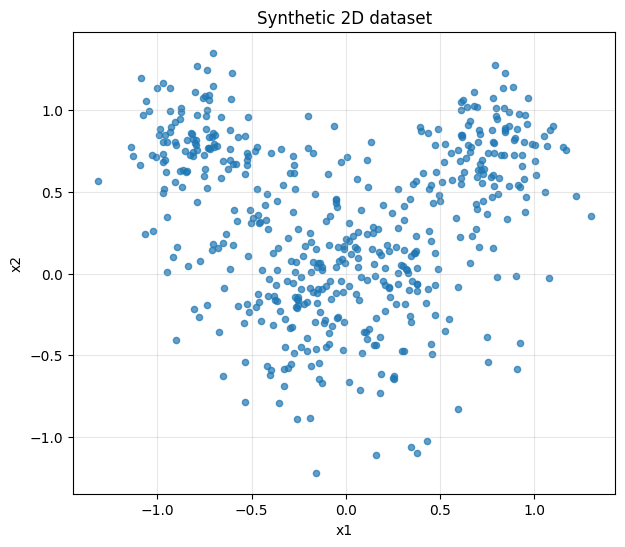

In [32]:
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.7)
plt.title("Synthetic 2D dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.show()

## Zbiór danych

Do części dotyczącej granicy decyzyjnej używam syntetycznego zbioru danych 2D z trzema klastrami. Zbiór został zbudowany z trzech rozkładów normalnych o różnych średnich i kowariancjach.

Taki wybór danych jest wygodny, ponieważ pozwala sprawdzić nie tylko standardowe przypisania punktów do klastrów, ale także to, jak model GMM zachowuje się w obszarach, w których granica decyzyjna może wyglądać mniej intuicyjnie.

In [33]:
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=0)
gmm.fit(X)

gmm_labels = gmm.predict(X)
gmm_proba = gmm.predict_proba(X)

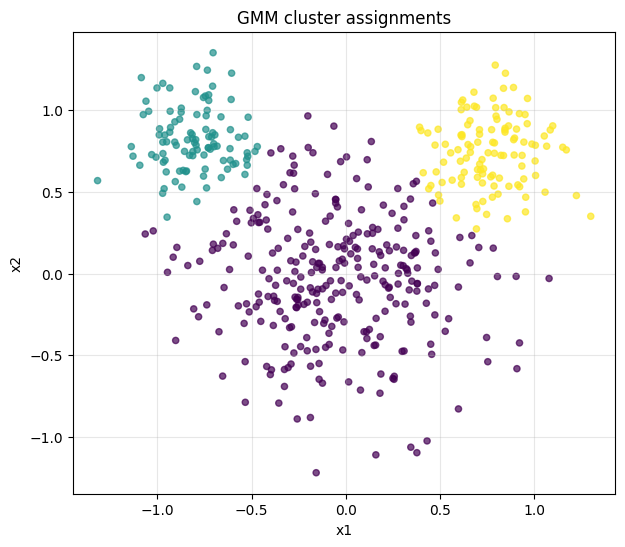

In [34]:
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, s=20, alpha=0.7)
plt.title("GMM cluster assignments")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.show()

In [35]:
x_min, x_max = X[:, 0].min() - 2, X[:, 0].max() + 2
y_min, y_max = X[:, 1].min() - 2, X[:, 1].max() + 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]

In [36]:
grid_labels = gmm.predict(grid)
grid_labels = grid_labels.reshape(xx.shape)

grid_proba = gmm.predict_proba(grid)
max_proba = grid_proba.max(axis=1).reshape(xx.shape)

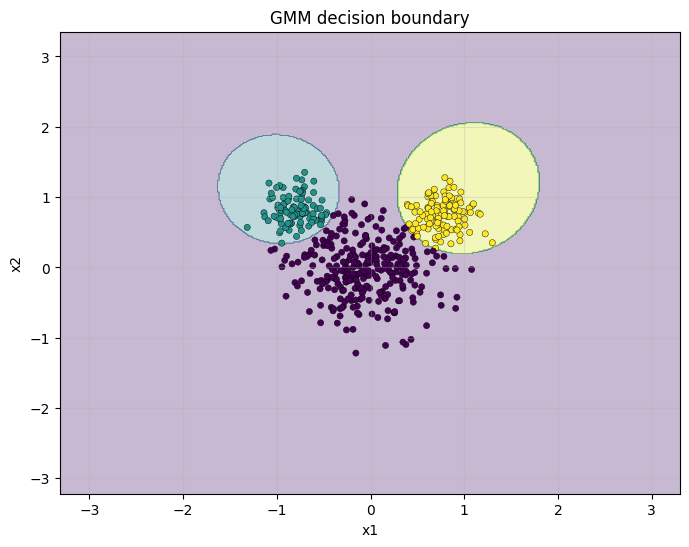

In [37]:
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, grid_labels, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, s=20, edgecolor="black", linewidth=0.3)

plt.title("GMM decision boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.show()

## Jak zwizualizować granicę decyzyjną GMM?

Do wizualizacji użyłem gęstej siatki $400 \times 400$, czyli 160 000 punktów, co pozwala dokładnie pokryć cały widoczny obszar wykresu.Granicę decyzyjną można zwizualizować przez pokrycie całej widocznej przestrzeni gęstą siatką punktów, a następnie przypisanie każdemu punktowi klastra o największym prawdopodobieństwie posteriori.

Dla każdego punktu $x$ wyznaczamy:

$$
\hat{k}(x) = \arg\max_k P(z = k \mid x)
$$

gdzie $P(z = k \mid x)$ oznacza odpowiedzialność klastra $k$ za punkt $x$.

Następnie kolorujemy cały obszar zgodnie z wartością $\hat{k}(x)$. Dzięki temu dla dowolnego punktu na wykresie od razu widać, do którego klastra zostałby przypisany przez model.

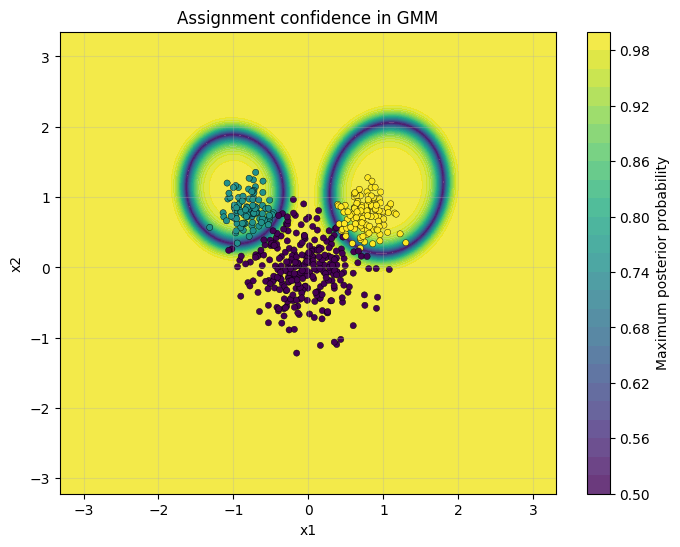

In [38]:
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, max_proba, levels=30, alpha=0.8)
plt.colorbar(label="Maximum posterior probability")

plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, s=20, edgecolor="black", linewidth=0.3)

plt.title("Assignment confidence in GMM")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.show()

## Interpretacja nieregularności na granicy decyzyjnej

Na wykresie widać, że dwa górne klastry zajmują tylko ograniczone obszary przestrzeni, a większość pozostałego obszaru zostaje przypisana do szerszego klastra środkowego. Może to wyglądać nieintuicyjnie, ale jest zgodne z działaniem GMM.

Model GMM nie przypisuje punktów wyłącznie na podstawie odległości od środka klastra. Uwzględnia również kowariancję oraz wagę każdego składnika mieszanki. W rezultacie klaster o większej wariancji może przejmować duże obszary przestrzeni, nawet daleko od swojej średniej.

Wykres maksymalnego prawdopodobieństwa posteriori pokazuje dodatkowo, że niepewność jest największa w pobliżu granic między klastrami, a maleje poza nimi.

## Jak wybrać liczbę klastrów?

Jeśli liczba klastrów nie jest znana z góry, można porównać wyniki dla różnych wartości $k$ i ocenić je za pomocą metryk jakości klastrowania.

W tej części użyję podziałów otrzymanych metodą KMeans i porównam je za pomocą:
- inertia,
- silhouette score.

Dla kilku wartości $k$ przedstawię wyniki na wykresach i sprawdzę, która liczba klastrów wydaje się najbardziej sensowna.

In [39]:
k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans_labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans_labels))

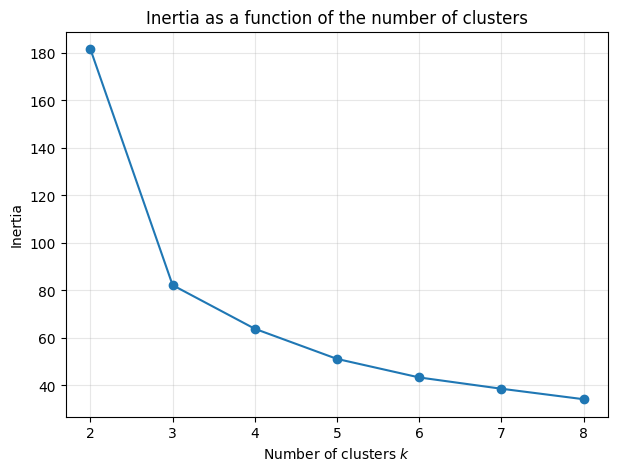

In [40]:
plt.figure(figsize=(7, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Inertia as a function of the number of clusters")
plt.xlabel("Number of clusters $k$")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

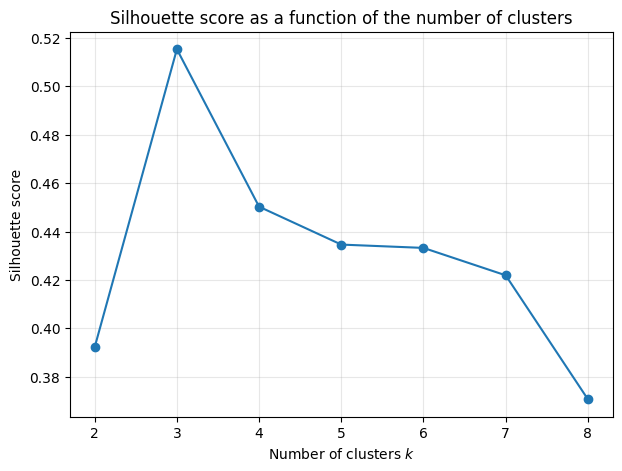

In [41]:
plt.figure(figsize=(7, 5))
plt.plot(list(k_values), silhouette_scores, marker="o")
plt.title("Silhouette score as a function of the number of clusters")
plt.xlabel("Number of clusters $k$")
plt.ylabel("Silhouette score")
plt.grid(alpha=0.3)
plt.show()

## Wybór liczby klastrów na podstawie metryk

Wykres inertia analizuje się metodą „łokcia”: szukamy takiej wartości $k$, od której dalsze zwiększanie liczby klastrów daje już tylko niewielką poprawę. W tym przypadku wyraźne załamanie pojawia się przy $k=3$.

Silhouette score należy maksymalizować: im wyższa wartość, tym lepsze rozdzielenie klastrów i większa spójność punktów wewnątrz grup. W tym przypadku najwyższa wartość silhouette score również występuje dla $k=3$.

Obie metryki wskazują więc, że dla badanego zbioru danych najbardziej sensownym wyborem jest $k=3$.

Wynik ten jest zgodny z konstrukcją badanego zbioru danych, który został wygenerowany z trzech składników.

In [42]:
best_idx = np.argmax(silhouette_scores)
best_k_silhouette = list(k_values)[best_idx]
best_silhouette = silhouette_scores[best_idx]

print(f"Best k according to silhouette score: {best_k_silhouette}")
print(f"Silhouette score for this k: {best_silhouette:.4f}")

Best k according to silhouette score: 3
Silhouette score for this k: 0.5153


## Wnioski

W części pierwszej pokazałem, że granicę decyzyjną GMM można zwizualizować przez ocenę gęstej siatki punktów i przypisanie każdemu punktowi klastra o największym prawdopodobieństwie posteriori. Taka mapa pokazuje, jak model dzieli całą przestrzeń, a nie tylko obserwowane dane. W badanym przykładzie było też widać, że granice mogą wyglądać nieintuicyjnie, ponieważ GMM uwzględnia nie tylko odległość od środka klastra, ale również kowariancję i wagę składników mieszanki.

W części drugiej porównałem różne wartości $k$ za pomocą inertia oraz silhouette score. Obie metryki wskazały, że dla tego zbioru danych najbardziej sensownym wyborem jest $k=3$.

Otrzymany wynik jest zgodny zarówno ze strukturą danych widoczną na wykresach, jak i z konstrukcją syntetycznego zbioru danych.

In [43]:
for k, inertia, sil in zip(k_values, inertias, silhouette_scores):
    print(f"k = {k}: inertia = {inertia:.2f}, silhouette score = {sil:.4f}")

k = 2: inertia = 181.59, silhouette score = 0.3922
k = 3: inertia = 82.22, silhouette score = 0.5153
k = 4: inertia = 63.85, silhouette score = 0.4503
k = 5: inertia = 51.16, silhouette score = 0.4346
k = 6: inertia = 43.35, silhouette score = 0.4332
k = 7: inertia = 38.59, silhouette score = 0.4219
k = 8: inertia = 34.18, silhouette score = 0.3707


## Komentarz do wyników liczbowych

Wypisane wartości metryk ułatwiają porównanie kolejnych wartości $k$. Dzięki nim można sprawdzić, czy maksimum silhouette score rzeczywiście pokrywa się z miejscem, w którym na wykresie inertia pojawia się „łokieć”.

Taki zapis jest dobrym uzupełnieniem wykresów, ponieważ pozwala odczytać dokładne wartości, a nie tylko ich ogólny trend.